In [15]:
!pip install annoy

In [16]:
from annoy import AnnoyIndex
import numpy as np
import pandas as pd
import joblib
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [17]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [19]:
CNN = joblib.load("/content/gdrive/MyDrive/ml/vggFinetune/cnnVGGFinetune.sav")
vgg = joblib.load('/content/gdrive/MyDrive/ml/vggFinetune/vggFinetune.sav')
stdScaler = joblib.load('/content/gdrive/MyDrive/ml/vggFinetune/stdScaler.pkl')
mmScaler = joblib.load('/content/gdrive/MyDrive/ml/vggFinetune/minMaxScaler.pkl')

In [20]:
df = pd.read_csv("/content/gdrive/MyDrive/ml/vggFinetune/trainValiVectors.csv")
filenames = df["filename"].values
vectors = df.drop(columns=["filename"]).values

In [21]:
vector_dim = vectors.shape[1]
ann_index = AnnoyIndex(vector_dim, metric='euclidean')

for i, v in enumerate(vectors):
    ann_index.add_item(i, v.tolist())

ann_index.build(1000)
ann_index.save("image_features.ann")

True

In [22]:
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [23]:
vgg.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_2          │ (None, 512)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [24]:
CNN.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 512)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529,408 (2.02 MB)

 Trainable params: 527,360 (2.01 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [30]:
def extract_feature(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    features = vgg.predict(x, verbose=0)
    features = features / np.linalg.norm(features, axis=1, keepdims=True)
    print(features)

    features = stdScaler.transform(features)
    features = CNN.predict(features, verbose=0)
    features = mmScaler.transform(features)
    return features.flatten()


In [26]:
def find_similar_images(img_path, top_k=10):
    query_vec = extract_feature(img_path)
    print(query_vec)
    print(query_vec.shape)
    idxs = ann_index.get_nns_by_vector(query_vec, top_k, include_distances=True)
    results = [(filenames[i], d) for i, d in zip(idxs[0], idxs[1])]
    return results

In [27]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

pathh = '/content/gdrive/MyDrive/ml/train+vali'

[[0.00000000e+00 4.91886493e-03 5.90820387e-02 0.00000000e+00
  1.37742376e-02 3.05550899e-02 1.72159206e-02 0.00000000e+00
  0.00000000e+00 5.36132716e-02 0.00000000e+00 0.00000000e+00
  6.58906996e-02 0.00000000e+00 6.44357689e-03 0.00000000e+00
  0.00000000e+00 5.98970838e-02 6.21766411e-03 0.00000000e+00
  1.05716130e-02 2.94286050e-02 1.15662767e-02 2.88027083e-03
  0.00000000e+00 0.00000000e+00 2.61162557e-02 6.73184097e-02
  7.41271675e-02 2.32870616e-02 0.00000000e+00 1.89744104e-02
  4.44537774e-02 0.00000000e+00 3.72263975e-02 6.30273074e-02
  4.97114426e-03 2.51338035e-02 3.49494927e-02 0.00000000e+00
  0.00000000e+00 1.30415075e-02 5.35936421e-03 1.05484165e-02
  6.60365522e-02 5.58160581e-02 3.65172215e-02 4.63227779e-02
  6.04705792e-03 4.33224142e-02 4.35914099e-02 0.00000000e+00
  2.30854433e-02 2.58673765e-02 6.99953884e-02 4.33789417e-02
  8.17051530e-03 3.80152860e-03 9.81400460e-02 0.00000000e+00
  0.00000000e+00 0.00000000e+00 8.68752319e-03 6.51895776e-02
  0.0000

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[[0.00000000e+00 4.91886493e-03 5.90820387e-02 0.00000000e+00
  1.37742376e-02 3.05550899e-02 1.72159206e-02 0.00000000e+00
  0.00000000e+00 5.36132716e-02 0.00000000e+00 0.00000000e+00
  6.58906996e-02 0.00000000e+00 6.44357689e-03 0.00000000e+00
  0.00000000e+00 5.98970838e-02 6.21766411e-03 0.00000000e+00
  1.05716130e-02 2.94286050e-02 1.15662767e-02 2.88027083e-03
  0.00000000e+00 0.00000000e+00 2.61162557e-02 6.73184097e-02
  7.41271675e-02 2.32870616e-02 0.00000000e+00 1.89744104e-02
  4.44537774e-02 0.00000000e+00 3.72263975e-02 6.30273074e-02
  4.97114426e-03 2.51338035e-02 3.49494927e-02 0.00000000e+00
  0.00000000e+00 1.30415075e-02 5.35936421e-03 1.05484165e-02
  6.60365522e-02 5.58160581e-02 3.65172215e-02 4.63227779e-02
  6.04705792e-03 4.33224142e-02 4.35914099e-02 0.00000000e+00
  2.30854433e-02 2.58673765e-02 6.99953884e-02 4.33789417e-02
  8.17051530e-03 3.80152860e-03 9.81400460e-02 0.00000000e+00
  0.00000000e+00 0.00000000e+00 8.68752319e-03 6.51895776e-02
  0.0000

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


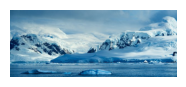

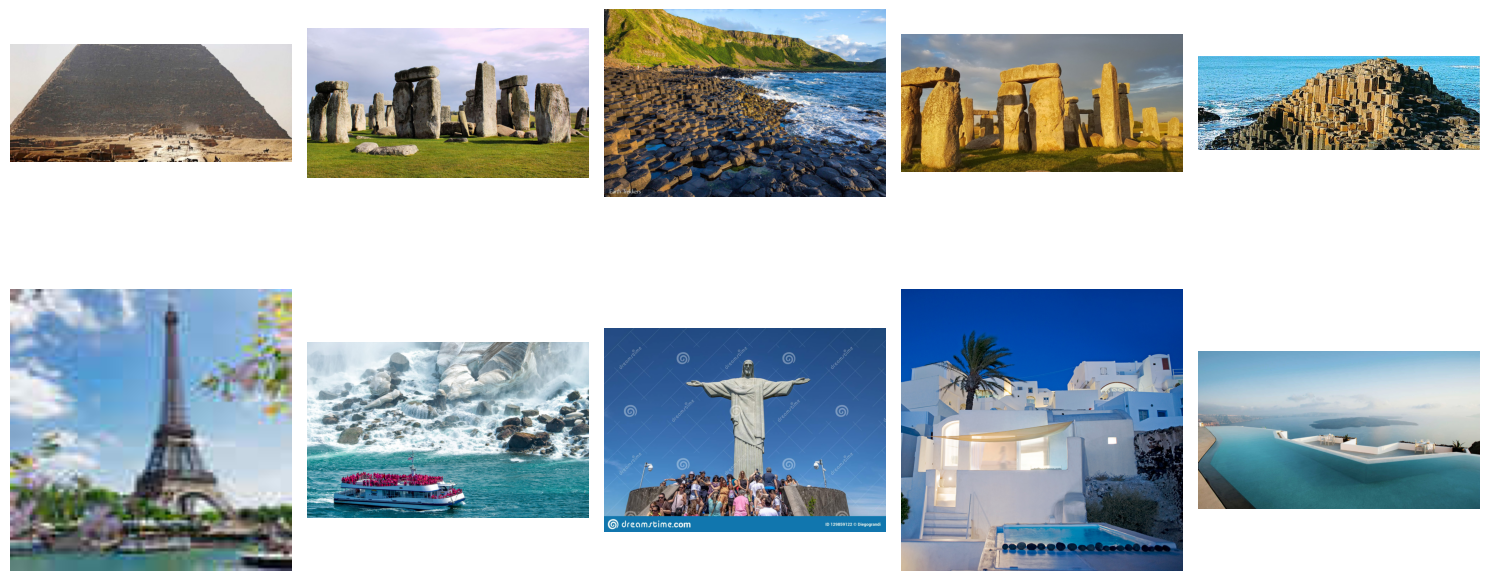

In [31]:
queryImg = "1.antarctica-stabbing-1_600.jpg"
similar = find_similar_images(queryImg)

# for fname, dist in similar:
#     print(f"{fname}  (distance={dist:.4f})")
similar = find_similar_images(queryImg)

plt.figure(figsize=(15, 8))
plt.subplot(2, 6, 1)
img = mpimg.imread(queryImg)
plt.imshow(img)
plt.axis('off')
plt.show()

plt.figure(figsize=(15, 8))
for i, (fname, dist) in enumerate(similar[:10], start=1):
    plt.subplot(2, 5, i)
    similar_image_full_path = os.path.join(pathh, fname)
    img = mpimg.imread(similar_image_full_path)
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()